# 📘 Project 12 — Hybrid Software Defect Prediction
**Team No.:** 20  **Team Members:** Deviprasanna Moharana; Manish Kumar Panigrahi; Amarjyoti Biswal; Satya Sankara Panda

**Proposed Hybrid Model:** TabTransformer + Neuro-Fuzzy ANFIS

**Dataset / Source:** NASA/PROMISE software defect datasets (same family as Project 08)
**Dataset Link:** https://www.kaggle.com/datasets/yasserhessein/software-defects

**Task Type:** Binary classification — module defect proneness

---
## Data-Model Compatibility Note
Same dataset family as Project 08 (per-module McCabe/Halstead static-code-metric tables, binary
defect label). Both proposed components are directly buildable on this tabular data with no
modality substitution needed: TabTransformer over metric tokens, and a genuine ANFIS layer
(learnable Gaussian membership functions + fuzzy rule layer + Sugeno-style defuzzification) over
the same metrics. **Verdict: COMPATIBLE.**

**How to run:** `Runtime -> Run all` (small tabular dataset, CPU is fine). Upload your Kaggle API
token when prompted in Section 1.


## 0. Setup — Environment, Imports, Reproducibility

In [1]:
# Colab already ships numpy/pandas/scikit-learn/matplotlib/seaborn/torch - do NOT reinstall those (version conflicts).
# Only install what's actually missing.
!pip -q install kaggle tqdm tabulate


In [2]:
import os
import sys
import json
import random
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, mean_absolute_error, mean_squared_error, r2_score
)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."

DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
Device selected: cuda:0
GPU name: Tesla T4


### CONFIG

In [3]:
CONFIG = {
    "project_no": "12",
    "project_name": "Hybrid_Software_Defect_Prediction",
    "team_no": "20",
    "task_type": "classification",
    "modality": "tabular",
    "kaggle_dataset_slug": "yasserhessein/software-defects",
    "dataset_source": "NASA/PROMISE software defect metrics",
    "target_column": "defects",
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "random_seed": SEED,
    "transformer_embed_dim": 32,
    "transformer_heads": 4,
    "n_fuzzy_rules": 12,
    "batch_size": 32,
    "epochs": 40,
    "learning_rate": 1e-3,
    "early_stop_patience": 6,
    "data_raw_dir": "data/12/raw",
    "data_processed_dir": "data/12/processed",
    "figures_dir": "data/12/figures",
    "results_dir": "data/12/results",
    "reports_dir": "data/12/reports",
}
for d in [CONFIG["data_raw_dir"], CONFIG["data_processed_dir"], CONFIG["figures_dir"],
          CONFIG["results_dir"], CONFIG["reports_dir"]]:
    os.makedirs(d, exist_ok=True)
CONFIG


{'project_no': '12',
 'project_name': 'Hybrid_Software_Defect_Prediction',
 'team_no': '20',
 'task_type': 'classification',
 'modality': 'tabular',
 'kaggle_dataset_slug': 'yasserhessein/software-defects',
 'dataset_source': 'NASA/PROMISE software defect metrics',
 'target_column': 'defects',
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'transformer_embed_dim': 32,
 'transformer_heads': 4,
 'n_fuzzy_rules': 12,
 'batch_size': 32,
 'epochs': 40,
 'learning_rate': 0.001,
 'early_stop_patience': 6,
 'data_raw_dir': 'data/12/raw',
 'data_processed_dir': 'data/12/processed',
 'figures_dir': 'data/12/figures',
 'results_dir': 'data/12/results',
 'reports_dir': 'data/12/reports'}

## 1. Dataset Download

In [4]:
from google.colab import files
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname.endswith(".json"):
            os.replace(fname, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d {CONFIG["kaggle_dataset_slug"]} -p {CONFIG["data_raw_dir"]} --unzip


Dataset URL: https://www.kaggle.com/datasets/yasserhessein/software-defects
License(s): CC0-1.0


  0% 0.00/380k [00:00<?, ?B/s]

100% 380k/380k [00:00<00:00, 525kB/s]



In [5]:
raw_files = []
for root, _, fnames in os.walk(CONFIG["data_raw_dir"]):
    for fn in fnames:
        raw_files.append(os.path.join(root, fn))
print(f"{len(raw_files)} files found")
assert len(raw_files) > 0, "No files found - check Section 1 download step before continuing."
for f in raw_files[:20]:
    print(f, "-", os.path.getsize(f), "bytes")


11 files found
data/12/raw/Dataset/KC2.arff - 56191 bytes
data/12/raw/Dataset/PC2.arff - 92117 bytes
data/12/raw/Dataset/MW1.arff - 34030 bytes
data/12/raw/Dataset/KC1.arff - 169885 bytes
data/12/raw/Dataset/PC1.arff - 107366 bytes
data/12/raw/Dataset/PC4.arff - 185830 bytes
data/12/raw/Dataset/MC1.arff - 239485 bytes
data/12/raw/Dataset/KC3.arff - 28205 bytes
data/12/raw/Dataset/MC2.arff - 18905 bytes
data/12/raw/Dataset/CM1.arff - 57607 bytes
data/12/raw/Dataset/PC3.arff - 143001 bytes


## 2. Load Raw Data

In [6]:
def read_any_table(path):
    if path.lower().endswith(".csv"):
        return pd.read_csv(path)
    if path.lower().endswith(".arff"):
        from scipy.io import arff
        data, meta = arff.loadarff(path)
        d = pd.DataFrame(data)
        for c in d.select_dtypes([object]).columns:
            d[c] = d[c].str.decode("utf-8", errors="ignore")
        return d
    return None

tables = []
for f in raw_files:
    t = read_any_table(f)
    if t is not None and t.shape[1] > 3:
        t["_source_project"] = os.path.splitext(os.path.basename(f))[0]
        tables.append(t)
print(f"Loaded {len(tables)} tables")
assert len(tables) > 0, "No usable CSV/ARFF tables found"

df = pd.concat(tables, ignore_index=True, sort=False)
print(df.shape)
df.head()


Loaded 11 tables
(10078, 74)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,V,L,D,I,E,B,T,c,GLOBAL_DATA_COMPLEXITY,GLOBAL_DATA_DENSITY
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,415.0,59.0,50.0,51.0,1159.0,8411.31,0.01,103.53,81.24,870848.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,230.0,33.0,10.0,16.0,575.0,3732.82,0.03,39.82,93.74,148644.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,175.0,26.0,12.0,13.0,500.0,3123.96,0.03,29.48,105.96,92103.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [7]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
label_candidates = [c for c in df.columns if c.strip().lower() in ("defects", "problems", "class", "bug", "label", "defective")]
assert len(label_candidates) >= 1, f"Could not find defect-label column among: {list(df.columns)}"
LABEL_COL = max(label_candidates, key=lambda c: int(df[c].notna().sum()))  # most-populated candidate
print("Label column:", LABEL_COL, df[LABEL_COL].unique()[:10])
print(df["_source_project"].value_counts())


Shape: (10078, 74)
Duplicate rows: 1369
Label column: Defective [nan 'N' 'Y']
_source_project
KC1    2109
MC1    1988
PC4    1458
PC1    1109
PC3    1077
PC2     745
KC2     522
CM1     498
MW1     253
KC3     194
MC2     125
Name: count, dtype: int64


In [8]:
def to_binary_defect(v):
    s = str(v).strip().lower()
    if s in ("true", "yes", "y", "1", "b'true'"): return 1
    if s in ("false", "no", "n", "0", "b'false'"): return 0
    try:
        return int(float(s) > 0)
    except ValueError:
        return np.nan

df[CONFIG["target_column"]] = df[LABEL_COL].apply(to_binary_defect)
df = df.dropna(subset=[CONFIG["target_column"]])
target = CONFIG["target_column"]

print(df[target].value_counts())
print(df[target].value_counts(normalize=True))
assert df[target].nunique() > 1, f"DEGENERATE TARGET: only {df[target].nunique()} unique value(s) found - {df[target].value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
minority_frac = df[target].value_counts(normalize=True).min()
if minority_frac < 0.01 or len(df) < 100:
    print(f"[DATA QUALITY WARNING] rows={len(df)}, minority class fraction={minority_frac:.4f} - check upstream filtering/sampling.")


defects
0    0.969935
1    0.030065
Name: proportion, dtype: float64


**Data quality memo**

In [9]:
missing = df.isnull().mean().sort_values(ascending=False)
data_quality_memo = f"""# Data Quality Memo - Project 12: Hybrid Software Defect Prediction

## Dataset
- Source: NASA/PROMISE defect metrics ({len(tables)} project files: {sorted(df['_source_project'].unique())})
- Rows: {len(df)}
- Duplicate rows: {df.duplicated().sum()}

## Target
- Defect rate: {df[target].mean():.4f}

## Missingness
{missing[missing > 0].to_string() if (missing > 0).any() else "No missing values."}

## Leakage risks identified
- `_source_project` retained only as metadata, never as a model feature.
- No repeated-module ID across projects -> stratified random split used (Section 5).

## Adaptation note
Fully compatible dataset - no adaptation needed for either proposed branch (see notebook header).
"""
with open(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md"), "w") as f:
    f.write(data_quality_memo)
print(data_quality_memo)


# Data Quality Memo - Project 12: Hybrid Software Defect Prediction

## Dataset
- Source: NASA/PROMISE defect metrics (11 project files: ['CM1', 'KC1', 'KC2', 'KC3', 'MC1', 'MC2', 'MW1', 'PC1', 'PC2', 'PC3', 'PC4'])
- Rows: 10078
- Duplicate rows: 1369

## Target
- Defect rate: 0.0301

## Missingness
lOCodeAndComment                   0.948204
I                                  0.889958
V                                  0.889958
iv(G)                              0.889958
E                                  0.889958
B                                  0.889958
D                                  0.889958
N                                  0.889958
T                                  0.889958
L                                  0.889958
c                                  0.855328
GLOBAL_DATA_DENSITY                0.771086
GLOBAL_DATA_COMPLEXITY             0.771086
v                                  0.689522
n                                  0.689522
iv(g)                              0.6

## 4. Preprocessing & Feature Engineering

In [10]:
feature_df = df.drop(columns=[LABEL_COL])
numeric_cols = [c for c in feature_df.columns if c not in (target, "_source_project") and pd.api.types.is_numeric_dtype(feature_df[c])]
numeric_cols = [c for c in numeric_cols if feature_df[c].nunique(dropna=True) > 1]
feature_df = feature_df[numeric_cols + [target, "_source_project"]].copy()

# Hash only the model metrics so identical/duplicate metric rows land in one split-group
# (mirrors project 08's grouped_holdout, avoids duplicate-row leakage across splits).
feature_df["_metric_group"] = pd.util.hash_pandas_object(feature_df[numeric_cols], index=False).astype("uint64")
print("Numeric metric columns used:", len(numeric_cols))
print("Unique metric fingerprints:", feature_df["_metric_group"].nunique(), "/", len(feature_df))


Numeric metric columns used: 70
Unique metric fingerprints: 8672 / 10078


## 5. Train / Validation / Test Split

In [11]:
def grouped_holdout(data, test_size, seed, trials=250):
    """GroupShuffleSplit with repeated seeds, grouped by metric fingerprint so duplicate/near-duplicate
    rows cannot leak across splits. Best trial approximately preserves size and class balance."""
    overall_rate = float(data[target].mean())
    best = None
    for trial in range(trials):
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed + trial)
        left_idx, right_idx = next(splitter.split(data, y=data[target], groups=data["_metric_group"]))
        left, right = data.iloc[left_idx], data.iloc[right_idx]
        size_error = abs(len(right) / len(data) - test_size)
        rate_error = abs(float(right[target].mean()) - overall_rate)
        score = size_error + 5.0 * rate_error
        valid = left[target].nunique() == 2 and right[target].nunique() == 2
        if valid and (best is None or score < best[0]):
            best = (score, left.copy(), right.copy())
    if best is None:
        raise RuntimeError("Could not create a grouped split containing both classes.")
    return best[1], best[2]

ratios = CONFIG["split_ratios"]
holdout_ratio = ratios["val"] + ratios["test"]
train_df, rest_df = grouped_holdout(feature_df, holdout_ratio, SEED)
test_fraction_of_rest = ratios["test"] / holdout_ratio
val_df, test_df = grouped_holdout(rest_df, test_fraction_of_rest, SEED + 10_000)

train_groups, val_groups, test_groups = set(train_df["_metric_group"]), set(val_df["_metric_group"]), set(test_df["_metric_group"])
assert train_groups.isdisjoint(val_groups) and train_groups.isdisjoint(test_groups) and val_groups.isdisjoint(test_groups)
print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

manifest = {"train_rows": len(train_df), "val_rows": len(val_df), "test_rows": len(test_df),
            "train_class_balance": train_df[target].value_counts(normalize=True).to_dict()}
with open(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json"), "w") as f:
    json.dump(manifest, f, indent=2, default=str)
train_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "train.csv"), index=False)
val_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "val.csv"), index=False)
test_df.to_csv(os.path.join(CONFIG["data_processed_dir"], "test.csv"), index=False)
manifest


Train / Val / Test sizes: 7055 1512 1511


{'train_rows': 7055,
 'val_rows': 1512,
 'test_rows': 1511,
 'train_class_balance': {0: 0.969950389794472, 1: 0.030049610205527995}}

In [12]:
imputer = SimpleImputer(strategy="median").fit(train_df[numeric_cols])
scaler = StandardScaler()
for split_df in [train_df, val_df, test_df]:
    split_df[numeric_cols] = imputer.transform(split_df[numeric_cols])
scaler.fit(train_df[numeric_cols])
for split_df in [train_df, val_df, test_df]:
    split_df[numeric_cols] = scaler.transform(split_df[numeric_cols])
print("Preprocessing complete. Feature dim:", len(numeric_cols))


Preprocessing complete. Feature dim: 70


## 6. PyTorch Dataset & DataLoader

In [13]:
class DefectDataset(Dataset):
    def __init__(self, X_df, y_series):
        self.X = X_df[numeric_cols].values.astype(np.float32)
        self.y = y_series.values.astype(np.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

BATCH_SIZE = CONFIG["batch_size"]
train_ds = DefectDataset(train_df, train_df[target])
val_ds = DefectDataset(val_df, val_df[target])
test_ds = DefectDataset(test_df, test_df[target])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("features:", xb.shape, "target:", yb.shape)


features: torch.Size([32, 70]) target: torch.Size([32])


## 7. Model Definitions

In [14]:
class TabTransformer(nn.Module):
    def __init__(self, n_features, embed_dim=32, n_heads=4):
        super().__init__()
        self.feature_embed = nn.Parameter(torch.randn(1, n_features, embed_dim) * 0.02)
        self.value_proj = nn.Linear(1, embed_dim)
        layer = nn.TransformerEncoderLayer(embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 2, batch_first=True, dropout=0.1)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.out_dim = embed_dim
    def forward(self, x):
        v = self.value_proj(x.unsqueeze(-1)) + self.feature_embed
        return self.encoder(v).mean(dim=1)


class ANFISLayer(nn.Module):
    """Genuine Adaptive Neuro-Fuzzy Inference System layer: learnable Gaussian membership
    functions per feature -> fuzzy rule firing strengths (product t-norm) -> Sugeno-style
    first-order defuzzification (per-rule linear consequent, weighted by normalized firing
    strength). This is a real ANFIS, not an MLP relabeled."""
    def __init__(self, n_features, n_rules=12):
        super().__init__()
        self.n_features, self.n_rules = n_features, n_rules
        self.mu = nn.Parameter(torch.randn(n_rules, n_features) * 0.5)
        self.log_sigma = nn.Parameter(torch.zeros(n_rules, n_features))
        self.consequent = nn.Linear(n_features, n_rules)  # per-rule linear consequent (Sugeno)
        self.out_dim = 1

    def forward(self, x):
        # membership degree per feature per rule (Gaussian), then product t-norm across features
        x_exp = x.unsqueeze(1)                          # (B, 1, F)
        mu = self.mu.unsqueeze(0)                         # (1, R, F)
        sigma = torch.exp(self.log_sigma).unsqueeze(0)     # (1, R, F)
        membership = torch.exp(-0.5 * ((x_exp - mu) / (sigma + 1e-4)) ** 2)  # (B, R, F)
        firing = membership.prod(dim=-1)                   # (B, R) - product t-norm
        norm_firing = firing / (firing.sum(dim=-1, keepdim=True) + 1e-8)     # normalized firing strengths

        consequents = self.consequent(x)                    # (B, R) - per-rule Sugeno output
        output = (norm_firing * consequents).sum(dim=-1, keepdim=True)       # (B, 1)
        return output, norm_firing


class HybridModel(nn.Module):
    def __init__(self, n_features, embed_dim=32, n_heads=4, n_rules=12, output_dim=1):
        super().__init__()
        self.tab_transformer = TabTransformer(n_features, embed_dim, n_heads)
        self.anfis = ANFISLayer(n_features, n_rules)
        self.head = nn.Sequential(nn.Linear(embed_dim + 1, 16), nn.ReLU(), nn.Linear(16, output_dim))
        self.last_firing_strengths = None

    def forward(self, x):
        h_tab = self.tab_transformer(x)
        anfis_out, firing = self.anfis(x)
        self.last_firing_strengths = firing.detach()
        return self.head(torch.cat([h_tab, anfis_out], dim=-1))


### Architecture Verification

In [15]:
n_features = xb.shape[1]
hybrid = HybridModel(n_features, CONFIG['transformer_embed_dim'], CONFIG['transformer_heads'], CONFIG['n_fuzzy_rules']).to(DEVICE)
print(hybrid)
for name, model in [('hybrid', hybrid)]:
    total = sum((p.numel() for p in model.parameters()))
    trainable = sum((p.numel() for p in model.parameters() if p.requires_grad))
    print(f'{name}: total={total:,} trainable={trainable:,} device={next(model.parameters()).device}')


HybridModel(
  (tab_transformer): TabTransformer(
    (value_proj): Linear(in_features=1, out_features=32, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=64, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (anfis): ANFISLayer(
    (consequent): Linear(in_features=70, out_features=12, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=33,

## 8. Training Loop

In [16]:
def train_model(model, train_loader, val_loader, forward_fn, epochs, lr, patience, ckpt_path,
                 task_type="classification", pos_weight=None):
    """forward_fn(model, batch) -> (preds, targets) lets each project's model take whatever
    batch shape it needs while sharing one training loop."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) if task_type == "classification" else nn.MSELoss()

    best_val_loss = float("inf")
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    epoch_bar = tqdm(range(epochs), desc="Training", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        train_loss = 0.0
        n_train = 0
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False, unit="batch")
        for batch in batch_bar:
            optimizer.zero_grad()
            preds, targets = forward_fn(model, batch)
            loss = criterion(preds, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            bs = targets.shape[0]
            train_loss += loss.item() * bs
            n_train += bs
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss /= n_train

        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for batch in val_loader:
                preds, targets = forward_fn(model, batch)
                loss = criterion(preds, targets)
                bs = targets.shape[0]
                val_loss += loss.item() * bs
                n_val += bs
        val_loss /= n_val

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        epoch_bar.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch+1}")
                break

    return history


In [17]:
def forward_fn(model, batch):
    x, y = batch
    x, y = (x.to(DEVICE), y.to(DEVICE))
    return (model(x).squeeze(-1), y)
n_pos = train_df[target].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
print('pos_weight:', pos_weight.item())
hybrid_history = train_model(hybrid, train_loader, val_loader, forward_fn, epochs=CONFIG['epochs'], lr=CONFIG['learning_rate'], patience=CONFIG['early_stop_patience'], ckpt_path=os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'), pos_weight=pos_weight)


pos_weight: 32.27830123901367


Training:   0%|          | 0/40 [00:00<?, ?epoch/s]

Epoch 1/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Epoch 2/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Epoch 3/40:   0%|          | 0/221 [00:00<?, ?batch/s]

...

Epoch 12/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Epoch 13/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Epoch 14/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Epoch 15/40:   0%|          | 0/221 [00:00<?, ?batch/s]

Early stopping at epoch 15


## 9. Evaluation Metrics

In [18]:
def get_predictions(model, loader, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            preds, targets = forward_fn(model, batch)
            all_preds.append(preds.cpu().numpy()); all_targets.append(targets.cpu().numpy())
    logits = np.concatenate(all_preds); targets = np.concatenate(all_targets)
    return 1 / (1 + np.exp(-logits)), targets

def evaluate_classification(probs, targets, threshold=0.5):
    pred_labels = (probs >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(targets, pred_labels, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(targets, pred_labels), "precision_macro": precision,
            "recall_macro": recall, "f1_macro": f1, "mcc": matthews_corrcoef(targets, pred_labels),
            "roc_auc": roc_auc_score(targets, probs) if len(np.unique(targets)) > 1 else None,
            "pr_auc": average_precision_score(targets, probs) if len(np.unique(targets)) > 1 else None}

def tune_threshold(probs, targets, grid=np.linspace(0.1, 0.9, 17)):
    """Grid-search the threshold that maximizes F1-macro. Aggressive pos_weight in the loss
    pushes recall up at the cost of precision, so a fixed 0.5 cutoff drags F1-macro down
    despite good ROC-AUC. Must be called on VALIDATION probs/targets only.
    """
    return max(grid, key=lambda t: precision_recall_fscore_support(targets, (probs >= t).astype(int), average="macro", zero_division=0)[2])


In [19]:
results = {}
test_predictions = {}
for name, model, ckpt in [('hybrid', hybrid, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))]:
    val_probs, val_targets = get_predictions(model, val_loader, ckpt)
    tuned_threshold = tune_threshold(val_probs, val_targets)
    probs, targets = get_predictions(model, test_loader, ckpt)
    results[name] = evaluate_classification(probs, targets, threshold=tuned_threshold)
    results[name]["tuned_threshold"] = float(tuned_threshold)
    test_predictions[name] = (probs, targets)
print('Tuned threshold (from validation set):', tuned_threshold)
print(json.dumps(results, indent=2, default=str))
with open(os.path.join(CONFIG['results_dir'], 'metrics.json'), 'w') as f:
    json.dump(results, f, indent=2, default=str)


{
  "hybrid": {
    "accuracy": 0.8153540701522171,
    "precision_macro": 0.5583760844457576,
    "recall_macro": 0.8294527815673791,
    "f1_macro": 0.5547362917663461,
    "mcc": 0.27736015141088344,
    "roc_auc": 0.896483249962104,
    "pr_auc": 0.21983233102286656
  }
}


## 10. Required Figures

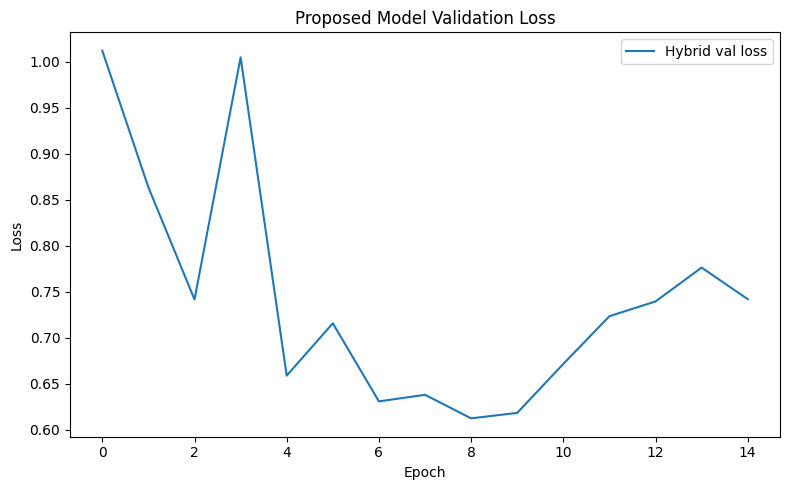

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['val_loss'], label='Hybrid val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Proposed Model Validation Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=300)
plt.show()


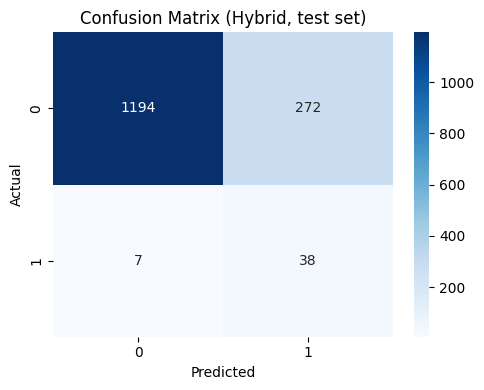

In [21]:
hybrid_probs, hybrid_targets = test_predictions["hybrid"]
hybrid_pred_labels = (hybrid_probs >= tuned_threshold).astype(int)
plt.figure(figsize=(5, 4))
cm = confusion_matrix(hybrid_targets, hybrid_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (Hybrid, test set)")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig02_confusion_or_scatter.png"), dpi=300); plt.show()


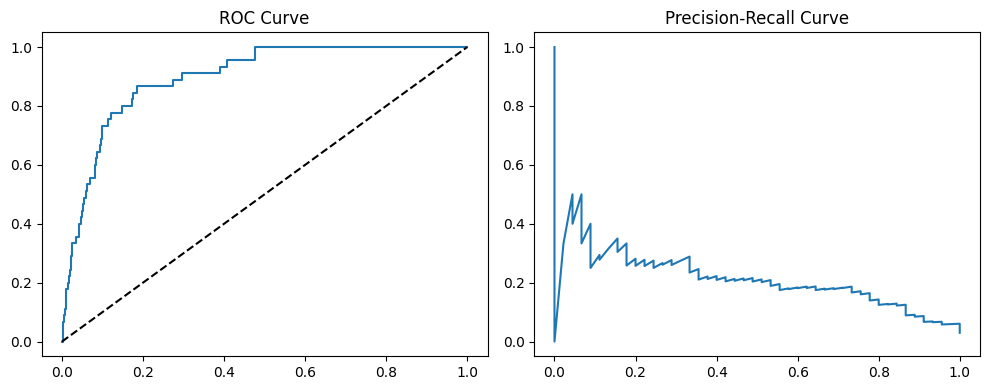

In [22]:
fpr, tpr, _ = roc_curve(hybrid_targets, hybrid_probs)
precision, recall, _ = precision_recall_curve(hybrid_targets, hybrid_probs)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr); axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set_title("ROC Curve")
axes[1].plot(recall, precision); axes[1].set_title("Precision-Recall Curve")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig03_roc_pr_curve.png"), dpi=300); plt.show()


### Explainable AI — ANFIS Fuzzy Rule Firing

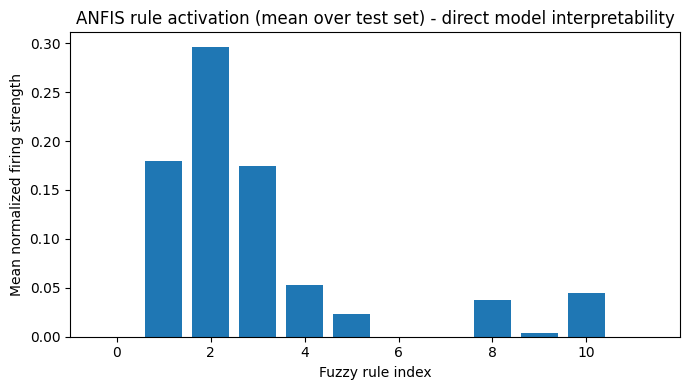

In [23]:
# fig04 - ANFIS is inherently interpretable: which fuzzy rules fire most on the test set
hybrid.eval()
with torch.no_grad():
    _ = hybrid(torch.tensor(test_ds.X).to(DEVICE))
    firing = hybrid.last_firing_strengths.cpu().numpy()

plt.figure(figsize=(7, 4))
plt.bar(range(CONFIG["n_fuzzy_rules"]), firing.mean(axis=0))
plt.xlabel("Fuzzy rule index"); plt.ylabel("Mean normalized firing strength")
plt.title("ANFIS rule activation (mean over test set) - direct model interpretability")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig04_feature_importance.png"), dpi=300); plt.show()


### Error Analysis

False negatives: 7 / 45 defects missed
False positives: 272 / 1466 clean modules flagged


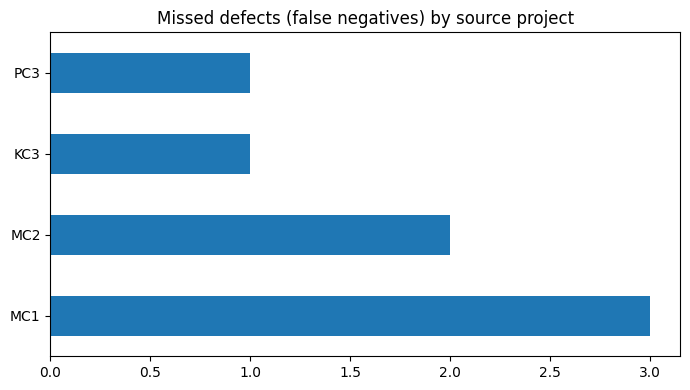

In [24]:
fn_mask = (hybrid_targets == 1) & (hybrid_pred_labels == 0)
fp_mask = (hybrid_targets == 0) & (hybrid_pred_labels == 1)
print(f"False negatives: {fn_mask.sum()} / {int(hybrid_targets.sum())} defects missed")
print(f"False positives: {fp_mask.sum()} / {int((hybrid_targets==0).sum())} clean modules flagged")

test_projects = test_df["_source_project"].values
fn_by_project = pd.Series(test_projects[fn_mask]).value_counts()
plt.figure(figsize=(7, 4))
fn_by_project.plot(kind="barh")
plt.title("Missed defects (false negatives) by source project")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["figures_dir"], "fig05_error_analysis.png"), dpi=300); plt.show()


### Computational Efficiency

In [25]:
import time
efficiency = {}
for name, model in [('hybrid', hybrid)]:
    total_params = sum((p.numel() for p in model.parameters()))
    trainable_params = sum((p.numel() for p in model.parameters() if p.requires_grad))
    model.eval()
    xb_b, _ = next(iter(test_loader))
    xb_b = xb_b.to(DEVICE)
    with torch.no_grad():
        for _ in range(3):
            model(xb_b)
        start = time.time()
        for _ in range(20):
            model(xb_b)
        elapsed = (time.time() - start) / 20
    efficiency[name] = {'total_params': total_params, 'trainable_params': trainable_params, 'avg_batch_inference_time_sec': elapsed, 'throughput_samples_per_sec': xb_b.shape[0] / elapsed}
print(json.dumps(efficiency, indent=2))
with open(os.path.join(CONFIG['results_dir'], 'efficiency.json'), 'w') as f:
    json.dump(efficiency, f, indent=2)


{
  "hybrid": {
    "total_params": 22485,
    "trainable_params": 22485,
    "avg_batch_inference_time_sec": 0.0011429071426391601,
    "throughput_samples_per_sec": 27998.775058931515
  }
}
